In [1]:
import torchvision

**importing dependencies**

In [2]:
# Install Dependencies
!pip install timm --quiet
!pip install seaborn --quiet

#  Imports and Device Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm.notebook import tqdm  # safer for notebooks
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#  Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Optional: set torch backend for performance on GPU
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda


**Dataset loading**

In [3]:
# 3. Dataset Preparation (CIFAR-100)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_dataset  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

**Loading Baseline models and adding gating function**

In [ ]:
import torch
import torch.nn as nn
import timm

class HybridCNNViT(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()

        # 1. BACKBONES (SMALL MODELS FOR COLAB FREE)
        self.cnn = timm.create_model(
            "convnext_nano",
            pretrained=True,
            num_classes=0
        )
        
        self.vit = timm.create_model(
            "vit_tiny_patch16_224",
            pretrained=True,
            num_classes=0
        )

        # 2. DETECT FEATURE DIMENSIONS 
        self.cnn_out = self._get_output_dim(self.cnn)
        self.vit_out = self._get_output_dim(self.vit)

        print(f"Detected CNN feature dim: {self.cnn_out}")
        print(f"Detected ViT feature dim: {self.vit_out}")

        # 3. PROJECT BOTH TO SAME SIZE = 512
        self.proj_cnn = nn.Linear(self.cnn_out, 512)
        self.proj_vit = nn.Linear(self.vit_out, 512)

        # 4. GATING NETWORK
        self.gate = nn.Sequential(
            nn.Linear(512 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 2),
            nn.Softmax(dim=1)
        )

        # 5. CLASSIFIER
        self.classifier = nn.Linear(512, num_classes)

    # FUNCTION TO AUTO-DETECT MODEL OUTPUT DIMENSIONS
    def _get_output_dim(self, model):
        dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            out = model(dummy)
        return out.shape[1]   # number of features

    # FORWARD PASS
    def forward(self, x):

        # CNN path
        f_cnn = self.proj_cnn(self.cnn(x))

        # ViT path
        f_vit = self.proj_vit(self.vit(x))

        # Combine for gating
        combined = torch.cat([f_cnn, f_vit], dim=1)
        weights = self.gate(combined)

        w_cnn = weights[:, 0].unsqueeze(1)
        w_vit = weights[:, 1].unsqueeze(1)

        # Weighted fusion
        fused = w_cnn * f_cnn + w_vit * f_vit

        # Classification
        return self.classifier(fused)


**Utility functions for training**

In [5]:
import torch.nn.functional as F
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    total_loss = 0

    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            preds = model(imgs)
            loss = F.cross_entropy(preds, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            _, predicted = torch.max(preds.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total




def evaluate_loss(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = F.cross_entropy(preds, labels)
            total_loss += loss.item()

    return total_loss / len(loader)


**Training Simple model**

In [11]:
from torch.cuda.amp import GradScaler, autocast
import torch
import pickle
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

hybrid_model = HybridCNNViT(num_classes=100).to(device)

optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=1e-4)
scaler = GradScaler()
epochs = 10

history_file = "training_history.pkl"
checkpoint_file = "hybrid_best.pth"

# =====================
# 1) Load history if exists
# =====================
if os.path.exists(history_file):
    with open(history_file, "rb") as f:
        history = pickle.load(f)
    print("Loaded existing training history.")
else:
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

# =====================
# 2) Resume from checkpoint if exists
# =====================
start_epoch = 0
best_val_acc = 0.0
if os.path.exists(checkpoint_file):
    checkpoint = torch.load(checkpoint_file, map_location=device)
    hybrid_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch']
    best_val_acc = checkpoint['val_acc']
    print(f"Resuming from epoch {start_epoch} with best_val_acc={best_val_acc:.2f}%")

# =====================
# 3) Training loop
# =====================
for epoch in range(start_epoch, epochs):
    print(f"\nEPOCH {epoch+1}/{epochs}")

    train_loss = train_one_epoch(hybrid_model, train_loader, optimizer, scaler, device)
    train_acc = evaluate(hybrid_model, train_loader, device)
    val_loss = evaluate_loss(hybrid_model, test_loader, device)
    val_acc = evaluate(hybrid_model, test_loader, device)

    # Append to history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save checkpoint if best validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch+1,
            'model_state_dict': hybrid_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'val_acc': val_acc
        }, checkpoint_file)
        print(f"Saved best model at epoch {epoch+1}")

    # Save history every epoch
    with open(history_file, "wb") as f:
        pickle.dump(history, f)

# =====================
# 4) Save final model
# =====================
torch.save(hybrid_model.state_dict(), "hybrid_final.pth")
print("Final model saved to hybrid_final.pth")


/tmp/ipykernel_130/2591461889.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Detected CNN feature dim: 640
Detected ViT feature dim: 192

EPOCH 1/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]/tmp/ipykernel_130/1736498867.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 1.7149 | Train Acc: 74.06%
Val Loss:   1.0637 | Val Acc:   69.06%
Saved best model at epoch 1

EPOCH 2/10


Train Loss: 0.9019 | Train Acc: 81.08%
Val Loss:   0.9615 | Val Acc:   71.99%
Saved best model at epoch 2

EPOCH 3/10


...

Train Loss: 0.4068 | Train Acc: 91.54%
Val Loss:   0.9341 | Val Acc:   75.31%
Saved best model at epoch 6

EPOCH 7/10


Train Loss: 0.3550 | Train Acc: 90.47%
Val Loss:   1.0281 | Val Acc:   73.48%

EPOCH 8/10


Train Loss: 0.3137 | Train Acc: 92.44%
Val Loss:   1.0385 | Val Acc:   73.89%

EPOCH 9/10


Train Loss: 0.2814 | Train Acc: 93.81%
Val Loss:   1.0055 | Val Acc:   74.97%

EPOCH 10/10


Train Loss: 0.2527 | Train Acc: 93.79%
Val Loss:   1.0712 | Val Acc:   74.39%
Final model saved to hybrid_final.pth


**Training Fine tuned Model**

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import pickle
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load previous model and history
hybrid_model = HybridCNNViT(num_classes=100).to(device)

checkpoint_file = "hybrid_best.pth"
history_file = "training_history.pkl"

# Load checkpoint if exists
start_epoch = 0
best_val_acc = 0.0
if os.path.exists(checkpoint_file):
    checkpoint = torch.load(checkpoint_file, map_location=device)
    hybrid_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from checkpoint at epoch {checkpoint['epoch']} with val_acc={checkpoint['val_acc']:.2f}%")
    best_val_acc = checkpoint['val_acc']

# Load history
if os.path.exists(history_file):
    with open(history_file, "rb") as f:
        history = pickle.load(f)
else:
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

scaler = GradScaler()

# 1) Quick gating sanity check
hybrid_model.eval()
with torch.no_grad():
    imgs, _ = next(iter(train_loader))
    imgs = imgs.to(device)
    f_cnn = hybrid_model.proj_cnn(hybrid_model.cnn(imgs))
    f_vit = hybrid_model.proj_vit(hybrid_model.vit(imgs))
    combined = torch.cat([f_cnn, f_vit], dim=1)
    weights = hybrid_model.gate(combined)
    print("Sample gating weights:\n", weights[:8].cpu().numpy())


# 2) Warm up fusion head
# Freeze backbones
for p in hybrid_model.cnn.parameters():
    p.requires_grad = False
for p in hybrid_model.vit.parameters():
    p.requires_grad = False

# Define head params and optimizer
head_params = list(hybrid_model.proj_cnn.parameters()) + \
              list(hybrid_model.proj_vit.parameters()) + \
              list(hybrid_model.gate.parameters()) + \
              list(hybrid_model.classifier.parameters())

opt_head = torch.optim.Adam(head_params, lr=1e-3, weight_decay=1e-4)
warmup_epochs = 3

print("Warming up fusion head...")
for epoch in range(warmup_epochs):
    print(f"\nHEAD WARMUP EPOCH {epoch+1}/{warmup_epochs}")
    train_loss = train_one_epoch(hybrid_model, train_loader, opt_head, scaler, device)
    train_acc = evaluate(hybrid_model, train_loader, device)
    val_loss = evaluate_loss(hybrid_model, test_loader, device)
    val_acc = evaluate(hybrid_model, test_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")


# 3) Unfreeze backbones and set new optimizer + scheduler
for p in hybrid_model.cnn.parameters():
    p.requires_grad = True
for p in hybrid_model.vit.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam([
    {'params': hybrid_model.cnn.parameters(), 'lr': 2e-5},
    {'params': hybrid_model.vit.parameters(), 'lr': 2e-5},
    {'params': head_params, 'lr': 1e-4}
], weight_decay=1e-4)

total_finetune_epochs = 20
scheduler = CosineAnnealingLR(optimizer, T_max=total_finetune_epochs, eta_min=1e-6)

# 4) Fine-tuning loop with checkpointing
for epoch in range(total_finetune_epochs):
    print(f"\nFINETUNE EPOCH {epoch+1}/{total_finetune_epochs}")

    train_loss = train_one_epoch(hybrid_model, train_loader, optimizer, scaler, device)
    train_acc = evaluate(hybrid_model, train_loader, device)
    val_loss = evaluate_loss(hybrid_model, test_loader, device)
    val_acc = evaluate(hybrid_model, test_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Step scheduler
    scheduler.step()

    # Save checkpoint if best validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch+1,
            'model_state_dict': hybrid_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'val_acc': val_acc
        }, "hybrid_best.pth")
        print(f"Saved best model at epoch {epoch+1}")

    # Save history each epoch
    with open("training_history.pkl", "wb") as f:
        pickle.dump(history, f)

# 5) Save final fine-tuned model
torch.save(hybrid_model.state_dict(), "hybrid_finetuned.pth")
print("Fine-tuned model saved to hybrid_finetuned.pth")


Detected CNN feature dim: 640
Detected ViT feature dim: 192


/tmp/ipykernel_130/4158917922.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Loaded model from checkpoint at epoch 6 with val_acc=75.31%
Sample gating weights:
 [[0.46623367 0.53376627]
 [0.46610412 0.5338959 ]
 [0.5742345  0.42576548]
 [0.3751566  0.6248434 ]]
Warming up fusion head...

HEAD WARMUP EPOCH 1/3


Training:   0%|          | 0/12500 [00:00<?, ?it/s]/tmp/ipykernel_130/1736498867.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.4409 | Train Acc: 90.75%
Val Loss:   1.2549 | Val Acc:   73.75%

HEAD WARMUP EPOCH 2/3


...

Train Loss: 0.0024 | Train Acc: 99.96%
Val Loss:   2.5917 | Val Acc:   80.38%

FINETUNE EPOCH 17/20


Train Loss: 0.0020 | Train Acc: 99.97%
Val Loss:   2.3978 | Val Acc:   80.40%

FINETUNE EPOCH 18/20


Train Loss: 0.0013 | Train Acc: 99.97%
Val Loss:   2.3651 | Val Acc:   80.23%

FINETUNE EPOCH 19/20


Train Loss: 0.0012 | Train Acc: 99.98%
Val Loss:   2.2460 | Val Acc:   80.38%

FINETUNE EPOCH 20/20


Train Loss: 0.0010 | Train Acc: 99.98%
Val Loss:   2.1994 | Val Acc:   80.35%
Fine-tuned model saved to hybrid_finetuned.pth


**Visualizations**

Detected CNN feature dim: 640
Detected ViT feature dim: 192


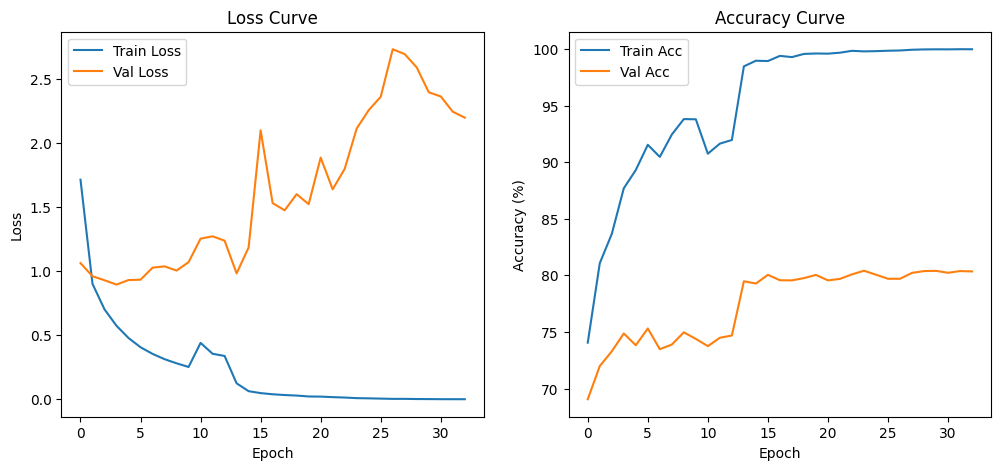

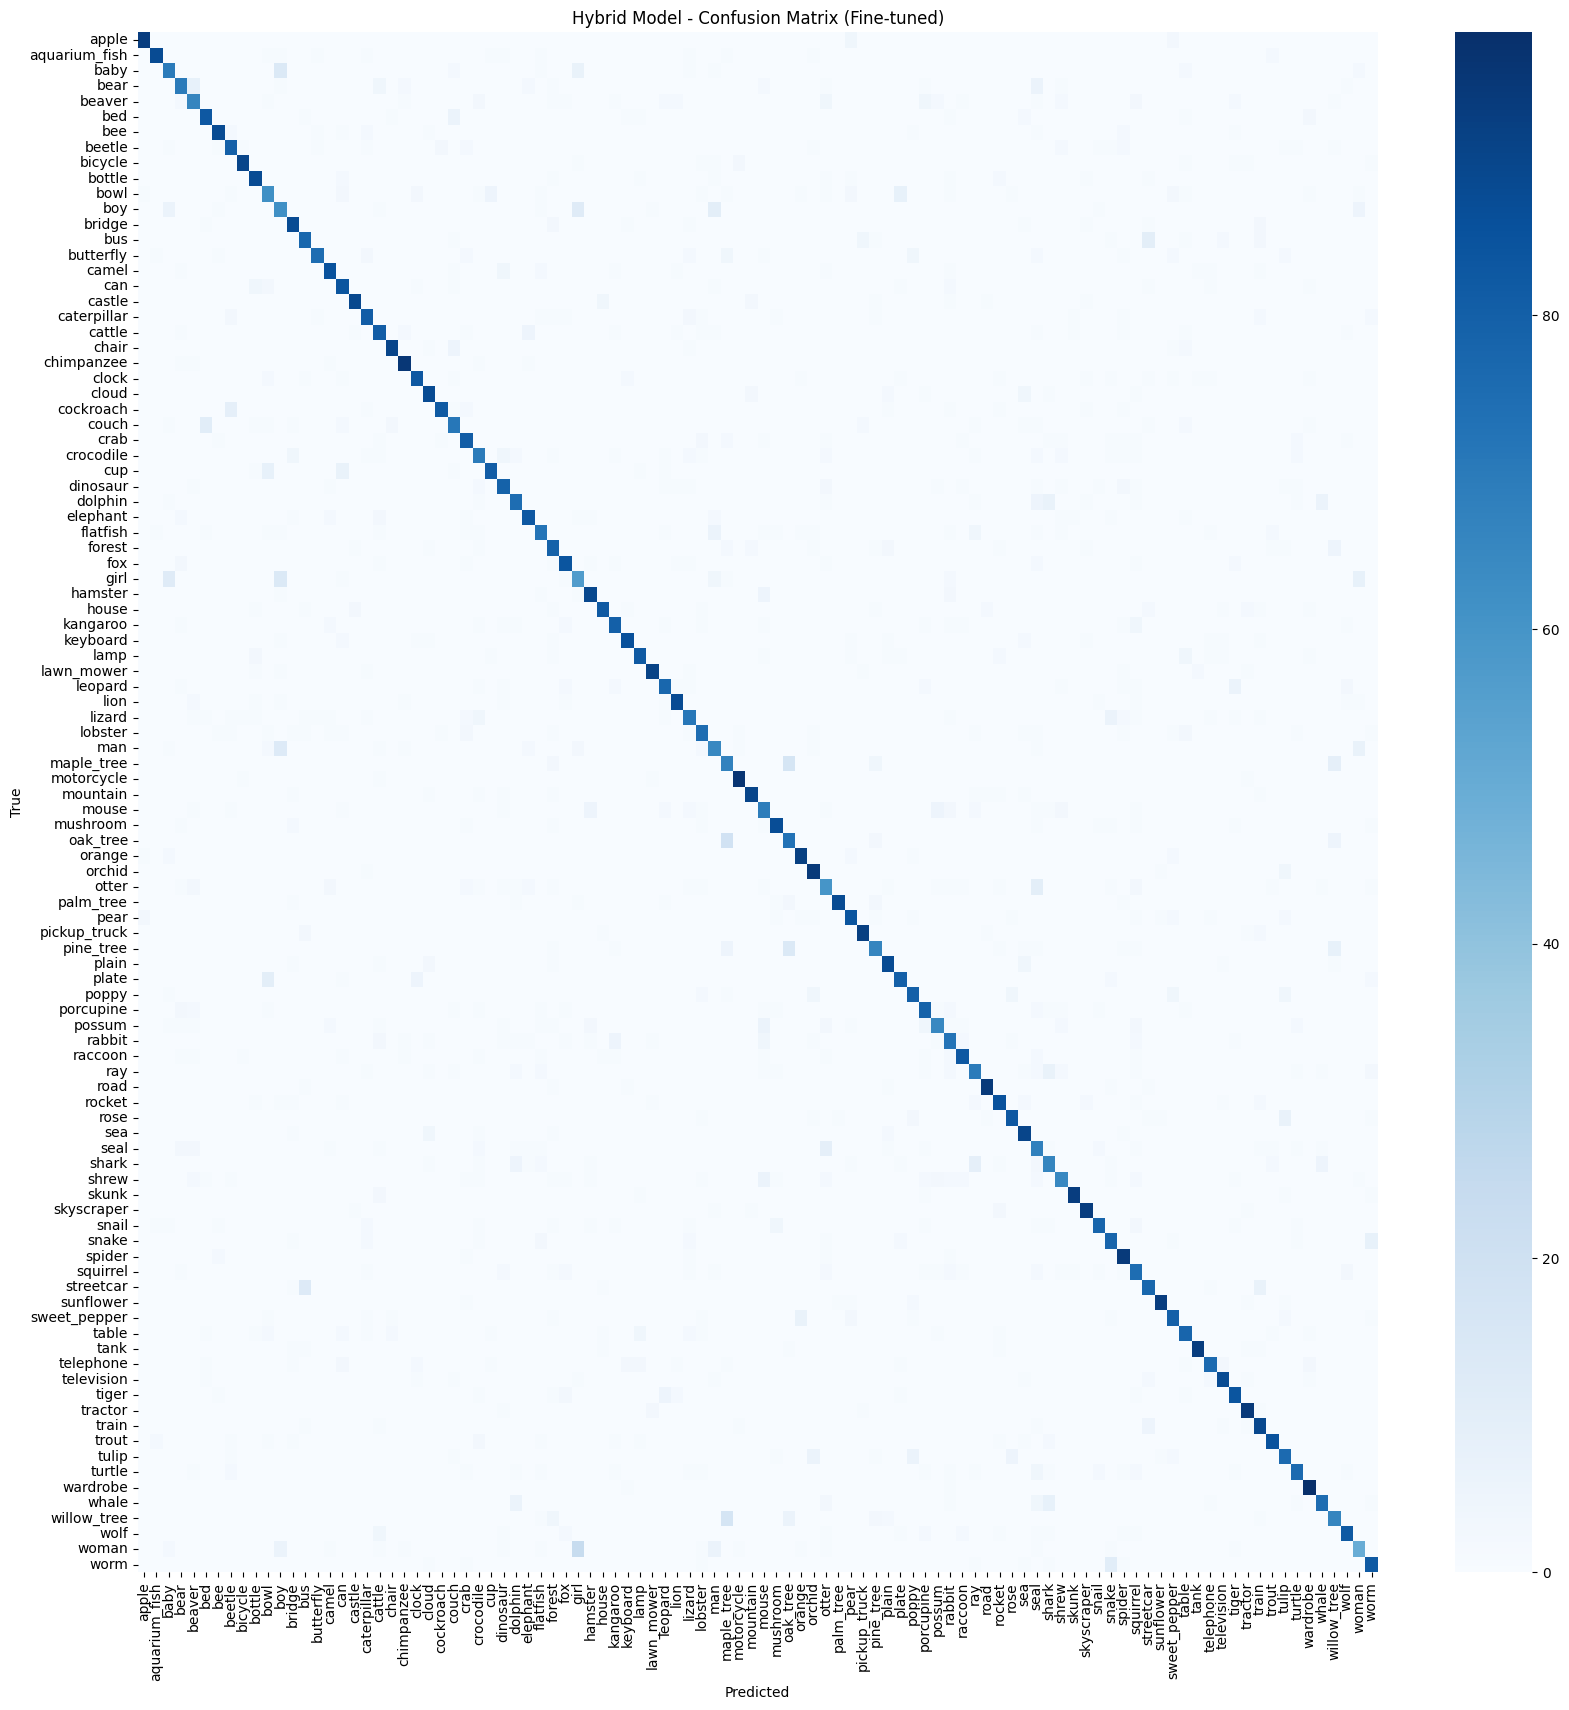

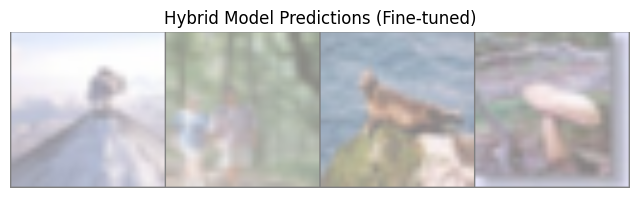

Predicted Labels:
1. road
2. forest
3. seal
4. mushroom


In [14]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import torchvision

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================
# 1) Load fine-tuned model
# =====================
hybrid_model = HybridCNNViT(num_classes=100).to(device)
checkpoint_file = "hybrid_finetuned.pth"  # fine-tuned model
hybrid_model.load_state_dict(torch.load(checkpoint_file, map_location=device))
hybrid_model.eval()

# =====================
# 2) Plot training history
# =====================
history_file = "training_history.pkl"
with open(history_file, "rb") as f:
    history = pickle.load(f)

def plot_training(history):
    plt.figure(figsize=(12,5))

    # Loss Curve
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy Curve
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.show()

plot_training(history)

# =====================
# 3) Confusion Matrix
# =====================
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = hybrid_model(imgs)
        _, predicted = torch.max(preds.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20,20))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Hybrid Model - Confusion Matrix (Fine-tuned)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# =====================
# 4) Image Predictions Visualization
# =====================
def imshow(img, title=""):
    img = img / 2 + 0.5  # unnormalize if needed
    npimg = img.numpy()
    plt.figure(figsize=(8,4))
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = hybrid_model(images)
    _, preds = torch.max(outputs, 1)

# Show at most 8 images
num_images = min(8, len(images))

imshow(torchvision.utils.make_grid(images[:num_images].cpu()),
       title="Hybrid Model Predictions (Fine-tuned)")

print("Predicted Labels:")
for i in range(num_images):
    print(f"{i+1}. {train_dataset.classes[preds[i].item()]}")



**Further Fine Tuning**

In [6]:
# FURTHER FINE-TUNING BLOCK
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torchvision import transforms
from tqdm import tqdm
import pickle
import os

device = "cuda" if torch.cuda.is_available() else "cpu"


In [7]:
# 1) Load previous fine-tuned model & history
hybrid_model = HybridCNNViT(num_classes=100).to(device)
checkpoint_file = "hybrid_finetuned.pth"

if os.path.exists(checkpoint_file):
    hybrid_model.load_state_dict(torch.load(checkpoint_file, map_location=device))
    print("Loaded previous fine-tuned model.")

# Start a history for the fine-tuned model
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}


Detected CNN feature dim: 640
Detected ViT feature dim: 192


In [8]:
# 2) Improved Data Augmentation
transform_train_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])
train_dataset.transform = transform_train_aug

In [9]:
# 3) Freeze/Unfreeze Strategy
for name, p in hybrid_model.named_parameters():
    if "cnn.stem" in name or "vit.patch_embed" in name:
        p.requires_grad = False  # freeze early layers
    else:
        p.requires_grad = True   # fine-tune deeper layers

In [10]:
# 4) Optimizer + Scheduler
head_params = list(hybrid_model.proj_cnn.parameters()) + \
              list(hybrid_model.proj_vit.parameters()) + \
              list(hybrid_model.gate.parameters()) + \
              list(hybrid_model.classifier.parameters())

optimizer = torch.optim.Adam([
    {'params': hybrid_model.cnn.parameters(), 'lr': 1e-5},
    {'params': hybrid_model.vit.parameters(), 'lr': 1e-5},
    {'params': head_params, 'lr': 1e-4}
], weight_decay=1e-4)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=1e-6)
scaler = GradScaler()

/tmp/ipykernel_144/1084565634.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [11]:
# 5) Mixup Helper Functions
def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = torch.distributions.Beta(alpha, alpha).sample().item()
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(pred, y_a, y_b, lam):
    return lam * F.cross_entropy(pred, y_a) + (1 - lam) * F.cross_entropy(pred, y_b)

In [12]:
# 6) Training Loop with Mixup + Label Smoothing
def train_one_epoch_hybrid(model, loader, optimizer, scaler, device, alpha=0.4, smoothing=0.1):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        # Mixup
        imgs, targets_a, targets_b, lam = mixup_data(imgs, labels, alpha)

        with autocast():
            preds = model(imgs)
            # Mixup + Label Smoothing
            n_classes = preds.size(1)
            # Label smoothing for targets_a
            smooth_a = torch.full_like(preds, smoothing / (n_classes - 1))
            smooth_a.scatter_(1, targets_a.unsqueeze(1), 1 - smoothing)
            # Label smoothing for targets_b
            smooth_b = torch.full_like(preds, smoothing / (n_classes - 1))
            smooth_b.scatter_(1, targets_b.unsqueeze(1), 1 - smoothing)
            # Mixup loss with smoothed labels
            log_preds = F.log_softmax(preds, dim=1)
            loss = lam * torch.mean(torch.sum(-smooth_a * log_preds, dim=1)) + \
                   (1 - lam) * torch.mean(torch.sum(-smooth_b * log_preds, dim=1))

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


In [13]:
# 7) Run Further Fine-Tuning
epochs = 10
best_val_acc = max(history["val_acc"]) if history["val_acc"] else 0

for epoch in range(epochs):
    print(f"\nFinal Hybrid Fine-Tuning Epoch {epoch+1}/{epochs}")

    train_loss = train_one_epoch_hybrid(hybrid_model, train_loader, optimizer, scaler, device, alpha=0.4, smoothing=0.1)
    train_acc = evaluate(hybrid_model, train_loader, device)
    val_loss = evaluate_loss(hybrid_model, test_loader, device)
    val_acc = evaluate(hybrid_model, test_loader, device)

    scheduler.step(epoch + 1)
    
    # Update history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(hybrid_model.state_dict(), "hybrid_best_finalFinetuned.pth")
        print(f"Saved best final model at epoch {epoch+1} with val_acc={val_acc:.2f}%")

# Save final model and history
torch.save(hybrid_model.state_dict(), "hybrid_final_all.pth")
with open("training_history_finalFinetuned.pkl", "wb") as f:
    pickle.dump(history, f)

print("final fine-tuning done. Model saved to hybrid_final_all.pth")


Final Hybrid Fine-Tuning Epoch 1/10


  0%|          | 0/12500 [00:00<?, ?it/s]/tmp/ipykernel_144/353681467.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Loss: 2.1418 | Train Acc: 85.96%
Val Loss:   0.6515 | Val Acc:   83.98%
Saved best final model at epoch 1 with val_acc=83.98%

Final Hybrid Fine-Tuning Epoch 2/10


Train Loss: 1.8293 | Train Acc: 89.86%
Val Loss:   0.6132 | Val Acc:   85.77%
Saved best final model at epoch 2 with val_acc=85.77%

Final Hybrid Fine-Tuning Epoch 3/10


Train Loss: 1.6999 | Train Acc: 92.48%
Val Loss:   0.5908 | Val Acc:   86.71%
Saved best final model at epoch 3 with val_acc=86.71%

Final Hybrid Fine-Tuning Epoch 4/10


...

Train Loss: 1.6531 | Train Acc: 93.68%
Val Loss:   0.6241 | Val Acc:   85.87%

Final Hybrid Fine-Tuning Epoch 7/10


Train Loss: 1.6160 | Train Acc: 94.59%
Val Loss:   0.6080 | Val Acc:   86.12%

Final Hybrid Fine-Tuning Epoch 8/10


Train Loss: 1.5542 | Train Acc: 96.84%
Val Loss:   0.5443 | Val Acc:   88.31%

Final Hybrid Fine-Tuning Epoch 9/10


Train Loss: 1.5042 | Train Acc: 97.95%
Val Loss:   0.6128 | Val Acc:   88.68%

Final Hybrid Fine-Tuning Epoch 10/10


Train Loss: 1.4566 | Train Acc: 98.55%
Val Loss:   0.5950 | Val Acc:   88.87%
final fine-tuning done. Model saved to hybrid_final_all.pth


**Final Visualizations overall**

Detected CNN feature dim: 640
Detected ViT feature dim: 192
Loaded hybrid_final_all.pth for visualization.


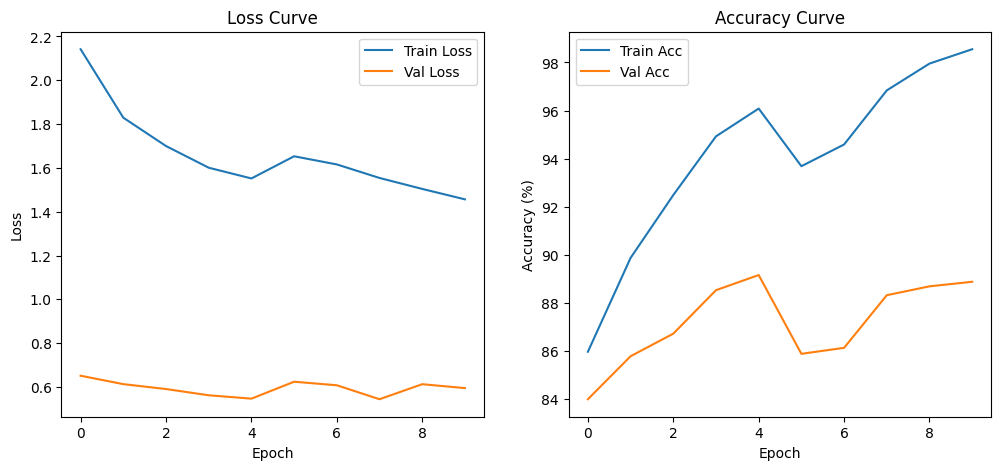

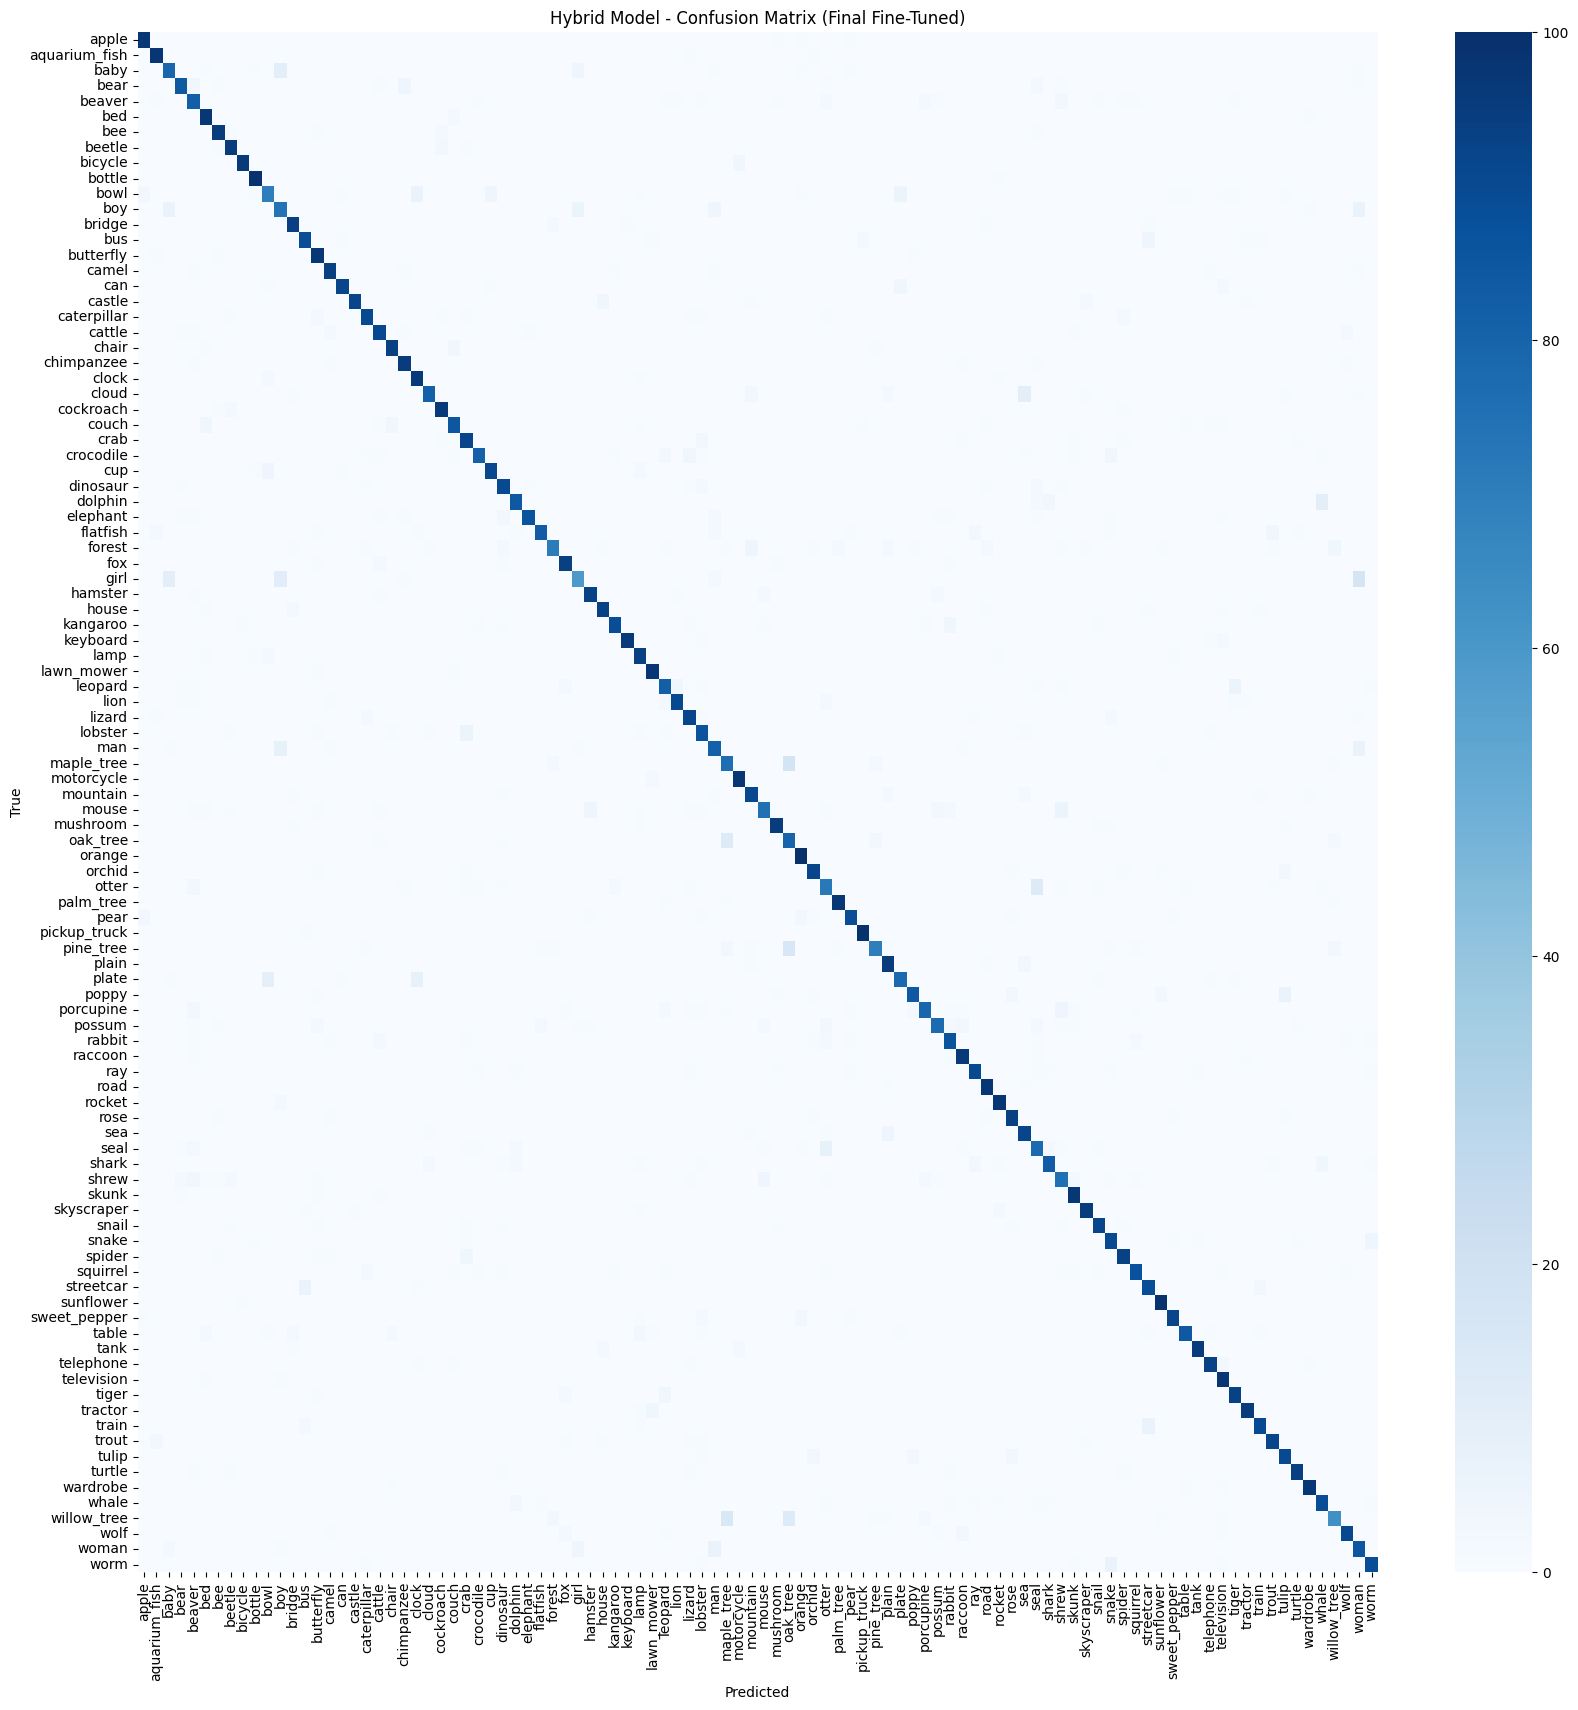


Classification Report:

               precision    recall  f1-score   support

        apple       0.93      0.97      0.95       100
aquarium_fish       0.92      0.98      0.95       100
         baby       0.79      0.79      0.79       100
         bear       0.90      0.84      0.87       100
       beaver       0.75      0.82      0.78       100
          bed       0.88      0.97      0.92       100
          bee       0.92      0.95      0.94       100
       beetle       0.90      0.95      0.93       100
      bicycle       0.98      0.96      0.97       100
       bottle       0.95      0.99      0.97       100
         bowl       0.78      0.70      0.74       100
          boy       0.69      0.74      0.71       100
       bridge       0.91      0.94      0.93       100
          bus       0.88      0.89      0.89       100
    butterfly       0.85      0.97      0.91       100
        camel       0.91      0.94      0.93       100
          can       0.96      0.92     

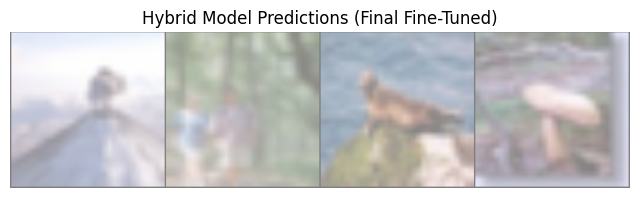

Predicted Labels:
1. mountain
2. forest
3. otter
4. mushroom


In [15]:
# Visualizations for Final Fine-Tuned Hybrid Model
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import torchvision
import pickle
from sklearn.metrics import classification_report


device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) Load final fine-tuned model
hybrid_model = HybridCNNViT(num_classes=100).to(device)
checkpoint_file = "hybrid_final_all.pth"
hybrid_model.load_state_dict(torch.load(checkpoint_file, map_location=device))
hybrid_model.eval()
print("Loaded hybrid_final_all.pth for visualization.")

# 2) Plot training history
history_file = "training_history_finalFinetuned.pkl"
with open(history_file, "rb") as f:
    history = pickle.load(f)

def plot_training(history):
    plt.figure(figsize=(12,5))

    # Loss Curve
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy Curve
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.show()

plot_training(history)

# 3) Confusion Matrix
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = hybrid_model(imgs)
        _, predicted = torch.max(preds.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20,20))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Hybrid Model - Confusion Matrix (Final Fine-Tuned)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Top-5 Accuracy
with torch.no_grad():
    top5_correct = 0
    total = 0
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = hybrid_model(imgs)
        _, top5_pred = outputs.topk(5, 1, True, True)
        top5_correct += sum([labels[i].item() in top5_pred[i].cpu().numpy() for i in range(labels.size(0))])
        total += labels.size(0)

top5_acc = 100 * top5_correct / total
print(f"Top-5 Accuracy: {top5_acc:.2f}%")

# 4) Sample Image Predictions
def imshow(img, title=""):
    img = img / 2 + 0.5  # unnormalize if needed
    npimg = img.numpy()
    plt.figure(figsize=(8,4))
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = hybrid_model(images)
    _, preds = torch.max(outputs, 1)

# Show at most 8 images
num_images = min(8, len(images))
imshow(torchvision.utils.make_grid(images[:num_images].cpu()),
       title="Hybrid Model Predictions (Final Fine-Tuned)")

print("Predicted Labels:")
for i in range(num_images):
    print(f"{i+1}. {train_dataset.classes[preds[i].item()]}")


**Final visualizations For best Model**

Detected CNN feature dim: 640
Detected ViT feature dim: 192
Loaded hybrid_final_all.pth for visualization.


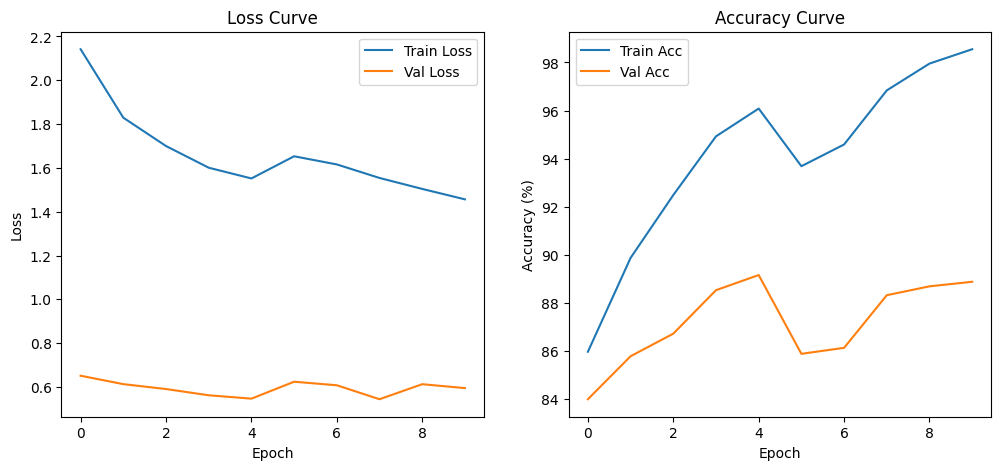

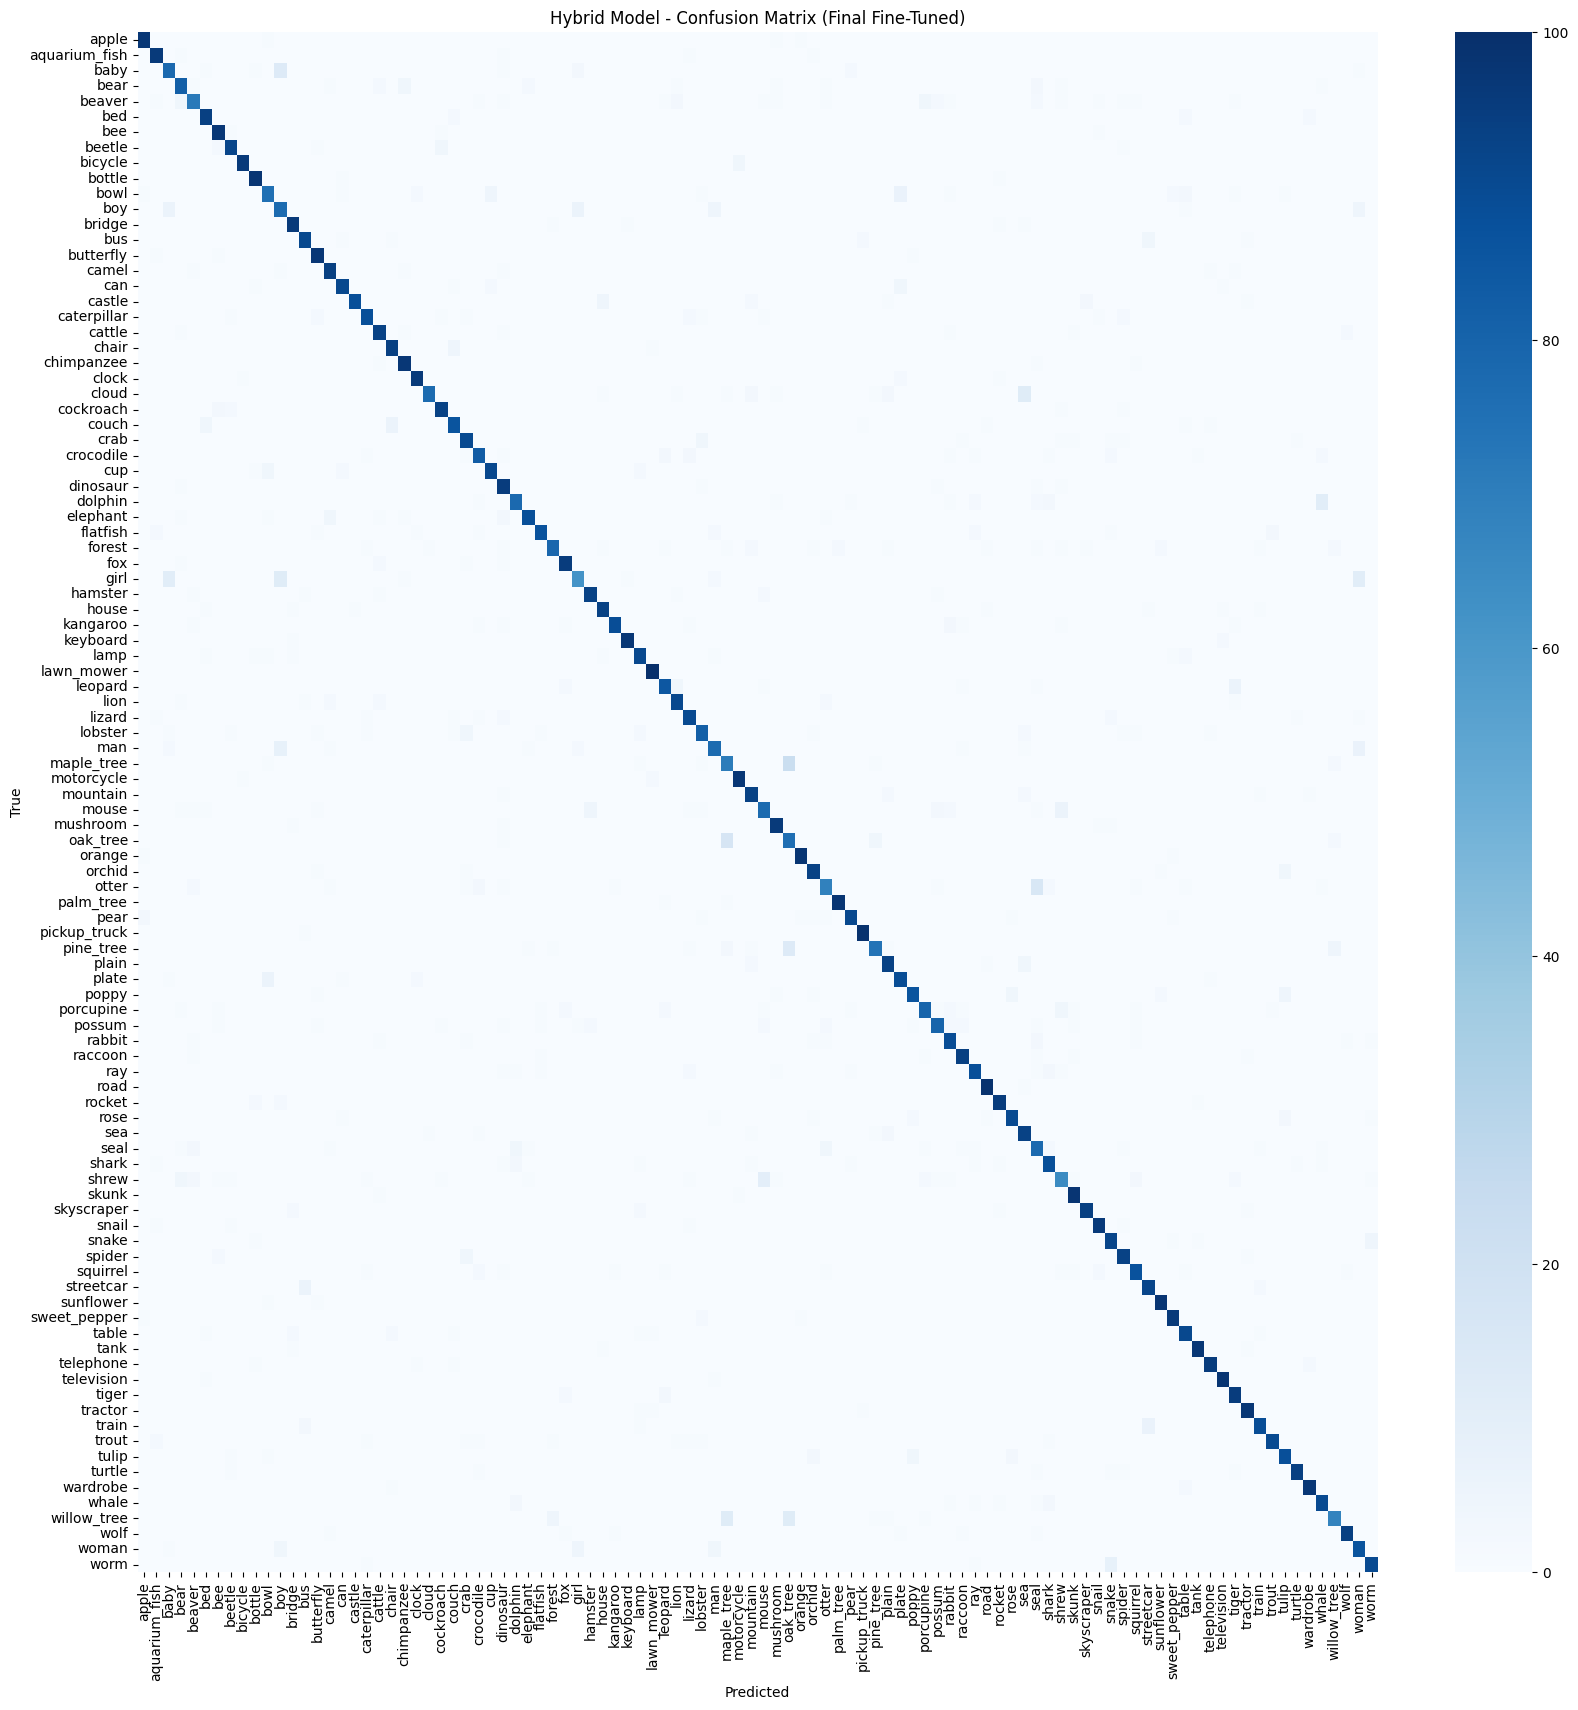


Classification Report:

               precision    recall  f1-score   support

        apple       0.94      0.97      0.96       100
aquarium_fish       0.91      0.96      0.94       100
         baby       0.78      0.78      0.78       100
         bear       0.83      0.82      0.82       100
       beaver       0.83      0.72      0.77       100
          bed       0.90      0.94      0.92       100
          bee       0.90      0.97      0.93       100
       beetle       0.91      0.92      0.92       100
      bicycle       0.98      0.96      0.97       100
       bottle       0.92      0.98      0.95       100
         bowl       0.82      0.75      0.79       100
          boy       0.66      0.77      0.71       100
       bridge       0.91      0.96      0.94       100
          bus       0.88      0.91      0.90       100
    butterfly       0.91      0.97      0.94       100
        camel       0.90      0.94      0.92       100
          can       0.93      0.91     

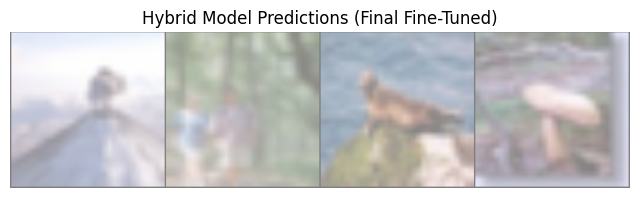

Predicted Labels:
1. mountain
2. forest
3. seal
4. mushroom


In [16]:
# Visualizations for Final Fine-Tuned Hybrid Model
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import torchvision
import pickle
from sklearn.metrics import classification_report


device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) Load final fine-tuned model
hybrid_model = HybridCNNViT(num_classes=100).to(device)
checkpoint_file = "hybrid_best_finalFinetuned.pth"
hybrid_model.load_state_dict(torch.load(checkpoint_file, map_location=device))
hybrid_model.eval()
print("Loaded hybrid_final_all.pth for visualization.")

# 2) Plot training history
history_file = "training_history_finalFinetuned.pkl"
with open(history_file, "rb") as f:
    history = pickle.load(f)

def plot_training(history):
    plt.figure(figsize=(12,5))

    # Loss Curve
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy Curve
    plt.subplot(1,2,2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.show()

plot_training(history)

# 3) Confusion Matrix
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = hybrid_model(imgs)
        _, predicted = torch.max(preds.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20,20))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Hybrid Model - Confusion Matrix (Final Fine-Tuned)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Top-5 Accuracy
with torch.no_grad():
    top5_correct = 0
    total = 0
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = hybrid_model(imgs)
        _, top5_pred = outputs.topk(5, 1, True, True)
        top5_correct += sum([labels[i].item() in top5_pred[i].cpu().numpy() for i in range(labels.size(0))])
        total += labels.size(0)

top5_acc = 100 * top5_correct / total
print(f"Top-5 Accuracy: {top5_acc:.2f}%")

# 4) Sample Image Predictions
def imshow(img, title=""):
    img = img / 2 + 0.5  # unnormalize if needed
    npimg = img.numpy()
    plt.figure(figsize=(8,4))
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = hybrid_model(images)
    _, preds = torch.max(outputs, 1)

# Show at most 8 images
num_images = min(8, len(images))
imshow(torchvision.utils.make_grid(images[:num_images].cpu()),
       title="Hybrid Model Predictions (Final Fine-Tuned)")

print("Predicted Labels:")
for i in range(num_images):
    print(f"{i+1}. {train_dataset.classes[preds[i].item()]}")


**Cross validation**

In [17]:
# 3-Fold Cross-Validation (Evaluation Only) for Hybrid CNN+ViT
import torch
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import KFold
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

# Dataset + Transform
transform_eval = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_eval)

# Load your further fine-tuned hybrid model
hybrid_model = HybridCNNViT(num_classes=100).to(device)
checkpoint_file = "hybrid_best_finalFinetuned.pth"
if os.path.exists(checkpoint_file):
    hybrid_model.load_state_dict(torch.load(checkpoint_file, map_location=device))
    hybrid_model.eval()
    print("Loaded hybrid_final_all.pth for evaluation.")
    
# Evaluation Function
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            _, predicted = torch.max(preds.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# 3-Fold CV
k_folds = 3
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(dataset)))):
    print(f"\n===== Fold {fold+1}/{k_folds} =====")
    
    val_subset = Subset(dataset, val_idx)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
    
    # Evaluate on this fold
    val_acc = evaluate(hybrid_model, val_loader, device)
    fold_accuracies.append(val_acc)
    print(f"Fold {fold+1} validation accuracy: {val_acc:.2f}%")

# Cross-Validated Results
mean_acc = sum(fold_accuracies) / k_folds
std_acc = (sum([(x - mean_acc) ** 2 for x in fold_accuracies]) / k_folds) ** 0.5
print(f"\n3-Fold Cross-Validated Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")


Detected CNN feature dim: 640
Detected ViT feature dim: 192
Loaded hybrid_final_all.pth for evaluation.

===== Fold 1/3 =====
Fold 1 validation accuracy: 96.45%

===== Fold 2/3 =====
Fold 2 validation accuracy: 96.39%

===== Fold 3/3 =====
Fold 3 validation accuracy: 96.44%

3-Fold Cross-Validated Accuracy: 96.42% ± 0.03%
